In [63]:
import pandas as pd
import missingno as missda
import numpy as np

In [64]:
data = pd.read_csv('gun-violence.csv')
data.head()

,incident_id,date,state,city_or_county,address,n_killed,n_injured,incident_url,source_url,incident_url_fields_missing,...,participant_age,participant_age_group,participant_gender,participant_name,participant_relationship,participant_status,participant_type,sources,state_house_district,state_senate_district
0,461105,1/1/2013,Pennsylvania,Mckeesport,1506 Versailles Avenue and Coursin Street,0,4,http://www.gunviolencearchive.org/incident/461105,http://www.post-gazette.com/local/south/2013/0...,False,...,0::20,0::Adult 18+||1::Adult 18+||2::Adult 18+||3::A...,0::Male||1::Male||3::Male||4::Female,0::Julian Sims,NaN,0::Arrested||1::Injured||2::Injured||3::Injure...,0::Victim||1::Victim||2::Victim||3::Victim||4:...,http://pittsburgh.cbslocal.com/2013/01/01/4-pe...,NaN,NaN
1,460726,1/1/2013,California,Hawthorne,13500 block of Cerise Avenue,1,3,http://www.gunviolencearchive.org/incident/460726,http://www.dailybulletin.com/article/zz/201301...,False,...,0::20,0::Adult 18+||1::Adult 18+||2::Adult 18+||3::A...,0::Male,0::Bernard Gillis,NaN,0::Killed||1::Injured||2::Injured||3::Injured,0::Victim||1::Victim||2::Victim||3::Victim||4:...,http://losangeles.cbslocal.com/2013/01/01/man-...,62.0,35.0
2,478855,1/1/2013,Ohio,Lorain,1776 East 28th Street,1,3,http://www.gunviolencearchive.org/incident/478855,http://chronicle.northcoastnow.com/2013/02/14/...,False,...,0::25||1::31||2::33||3::34||4::33,0::Adult 18+||1::Adult 18+||2::Adult 18+||3::A...,0::Male||1::Male||2::Male||3::Male||4::Male,0::Damien Bell||1::Desmen Noble||2::Herman Sea...,NaN,"0::Injured, Unharmed, Arrested||1::Unharmed, A...",0::Subject-Suspect||1::Subject-Suspect||2::Vic...,http://www.morningjournal.com/general-news/201...,56.0,13.0
3,478925,1/5/2013,Colorado,Aurora,16000 block of East Ithaca Place,4,0,http://www.gunviolencearchive.org/incident/478925,http://www.dailydemocrat.com/20130106/aurora-s...,False,...,0::29||1::33||2::56||3::33,0::Adult 18+||1::Adult 18+||2::Adult 18+||3::A...,0::Female||1::Male||2::Male||3::Male,0::Stacie Philbrook||1::Christopher Ratliffe||...,NaN,0::Killed||1::Killed||2::Killed||3::Killed,0::Victim||1::Victim||2::Victim||3::Subject-Su...,http://denver.cbslocal.com/2013/01/06/officer-...,40.0,28.0
4,478959,1/7/2013,North Carolina,Greensboro,307 Mourning Dove Terrace,2,2,http://www.gunviolencearchive.org/incident/478959,http://www.journalnow.com/news/local/article_d...,False,...,0::18||1::46||2::14||3::47,0::Adult 18+||1::Adult 18+||2::Teen 12-17||3::...,0::Female||1::Male||2::Male||3::Female,0::Danielle Imani Jameison||1::Maurice Eugene ...,3::Family,0::Injured||1::Injured||2::Killed||3::Killed,0::Victim||1::Victim||2::Victim||3::Subject-Su...,http://myfox8.com/2013/01/08/update-mother-sho...,62.0,27.0


In [65]:
data.drop(columns=['incident_characteristics','state_senate_district','congressional_district','state_house_district','address','incident_url','incident_url_fields_missing','source_url','longitude','latitude','sources','participant_name'],inplace=True)
data.head()

,incident_id,date,state,city_or_county,n_killed,n_injured,gun_stolen,gun_type,location_description,n_guns_involved,notes,participant_age,participant_age_group,participant_gender,participant_relationship,participant_status,participant_type
0,461105,1/1/2013,Pennsylvania,Mckeesport,0,4,NaN,NaN,NaN,NaN,Julian Sims under investigation: Four Shot and...,0::20,0::Adult 18+||1::Adult 18+||2::Adult 18+||3::A...,0::Male||1::Male||3::Male||4::Female,NaN,0::Arrested||1::Injured||2::Injured||3::Injure...,0::Victim||1::Victim||2::Victim||3::Victim||4:...
1,460726,1/1/2013,California,Hawthorne,1,3,NaN,NaN,NaN,NaN,Four Shot; One Killed; Unidentified shooter in...,0::20,0::Adult 18+||1::Adult 18+||2::Adult 18+||3::A...,0::Male,NaN,0::Killed||1::Injured||2::Injured||3::Injured,0::Victim||1::Victim||2::Victim||3::Victim||4:...
2,478855,1/1/2013,Ohio,Lorain,1,3,0::Unknown||1::Unknown,0::Unknown||1::Unknown,Cotton Club,2.0,NaN,0::25||1::31||2::33||3::34||4::33,0::Adult 18+||1::Adult 18+||2::Adult 18+||3::A...,0::Male||1::Male||2::Male||3::Male||4::Male,NaN,"0::Injured, Unharmed, Arrested||1::Unharmed, A...",0::Subject-Suspect||1::Subject-Suspect||2::Vic...
3,478925,1/5/2013,Colorado,Aurora,4,0,NaN,NaN,NaN,NaN,NaN,0::29||1::33||2::56||3::33,0::Adult 18+||1::Adult 18+||2::Adult 18+||3::A...,0::Female||1::Male||2::Male||3::Male,NaN,0::Killed||1::Killed||2::Killed||3::Killed,0::Victim||1::Victim||2::Victim||3::Subject-Su...
4,478959,1/7/2013,North Carolina,Greensboro,2,2,0::Unknown||1::Unknown,0::Handgun||1::Handgun,NaN,2.0,Two firearms recovered. (Attempted) murder sui...,0::18||1::46||2::14||3::47,0::Adult 18+||1::Adult 18+||2::Teen 12-17||3::...,0::Female||1::Male||2::Male||3::Female,3::Family,0::Injured||1::Injured||2::Killed||3::Killed,0::Victim||1::Victim||2::Victim||3::Subject-Su...


<Axes: >

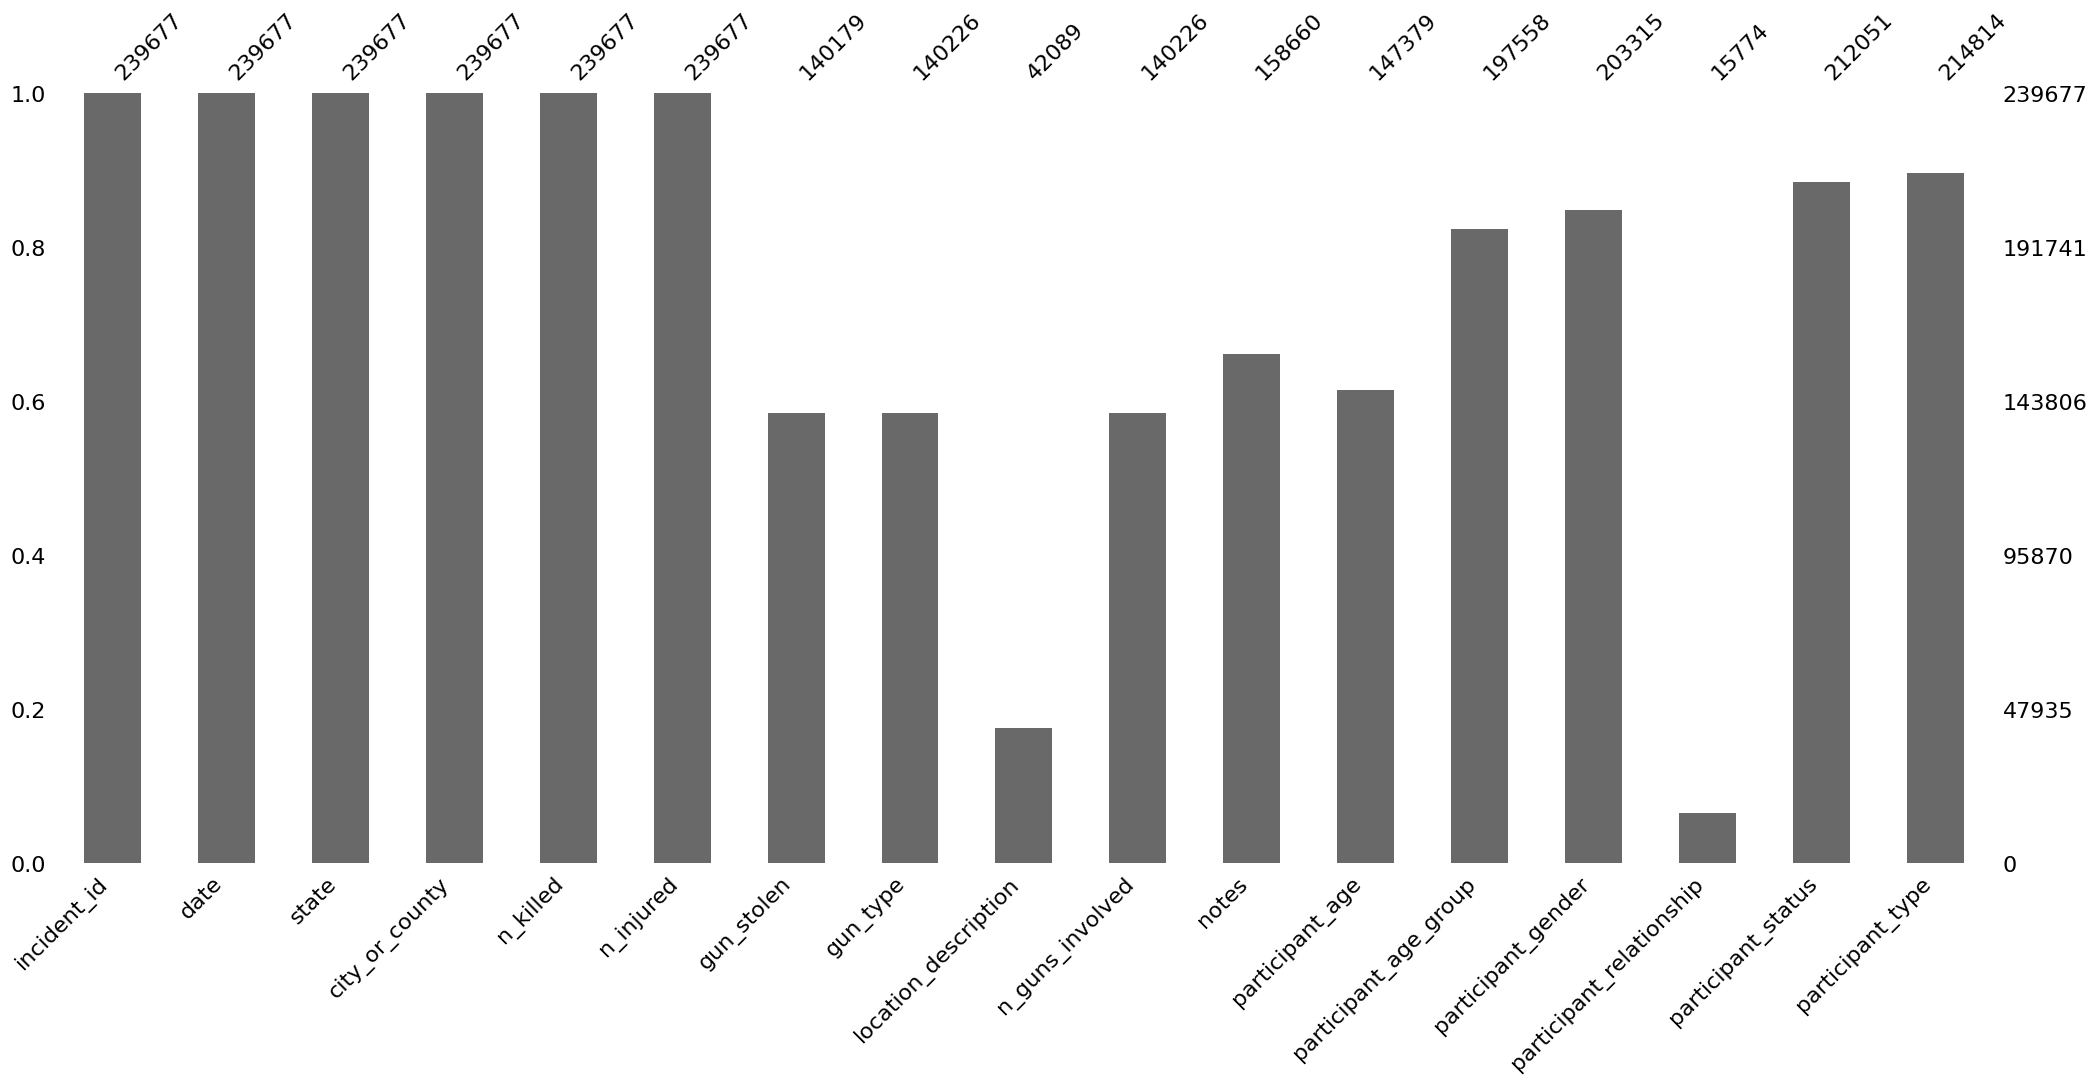

In [66]:
missda.bar(data)

In [67]:
data.drop(columns=['gun_stolen','gun_type','location_description','n_guns_involved','notes','participant_relationship','participant_age'],inplace=True)
data.head()

,incident_id,date,state,city_or_county,n_killed,n_injured,participant_age_group,participant_gender,participant_status,participant_type
0,461105,1/1/2013,Pennsylvania,Mckeesport,0,4,0::Adult 18+||1::Adult 18+||2::Adult 18+||3::A...,0::Male||1::Male||3::Male||4::Female,0::Arrested||1::Injured||2::Injured||3::Injure...,0::Victim||1::Victim||2::Victim||3::Victim||4:...
1,460726,1/1/2013,California,Hawthorne,1,3,0::Adult 18+||1::Adult 18+||2::Adult 18+||3::A...,0::Male,0::Killed||1::Injured||2::Injured||3::Injured,0::Victim||1::Victim||2::Victim||3::Victim||4:...
2,478855,1/1/2013,Ohio,Lorain,1,3,0::Adult 18+||1::Adult 18+||2::Adult 18+||3::A...,0::Male||1::Male||2::Male||3::Male||4::Male,"0::Injured, Unharmed, Arrested||1::Unharmed, A...",0::Subject-Suspect||1::Subject-Suspect||2::Vic...
3,478925,1/5/2013,Colorado,Aurora,4,0,0::Adult 18+||1::Adult 18+||2::Adult 18+||3::A...,0::Female||1::Male||2::Male||3::Male,0::Killed||1::Killed||2::Killed||3::Killed,0::Victim||1::Victim||2::Victim||3::Subject-Su...
4,478959,1/7/2013,North Carolina,Greensboro,2,2,0::Adult 18+||1::Adult 18+||2::Teen 12-17||3::...,0::Female||1::Male||2::Male||3::Female,0::Injured||1::Injured||2::Killed||3::Killed,0::Victim||1::Victim||2::Victim||3::Subject-Su...


<Axes: >

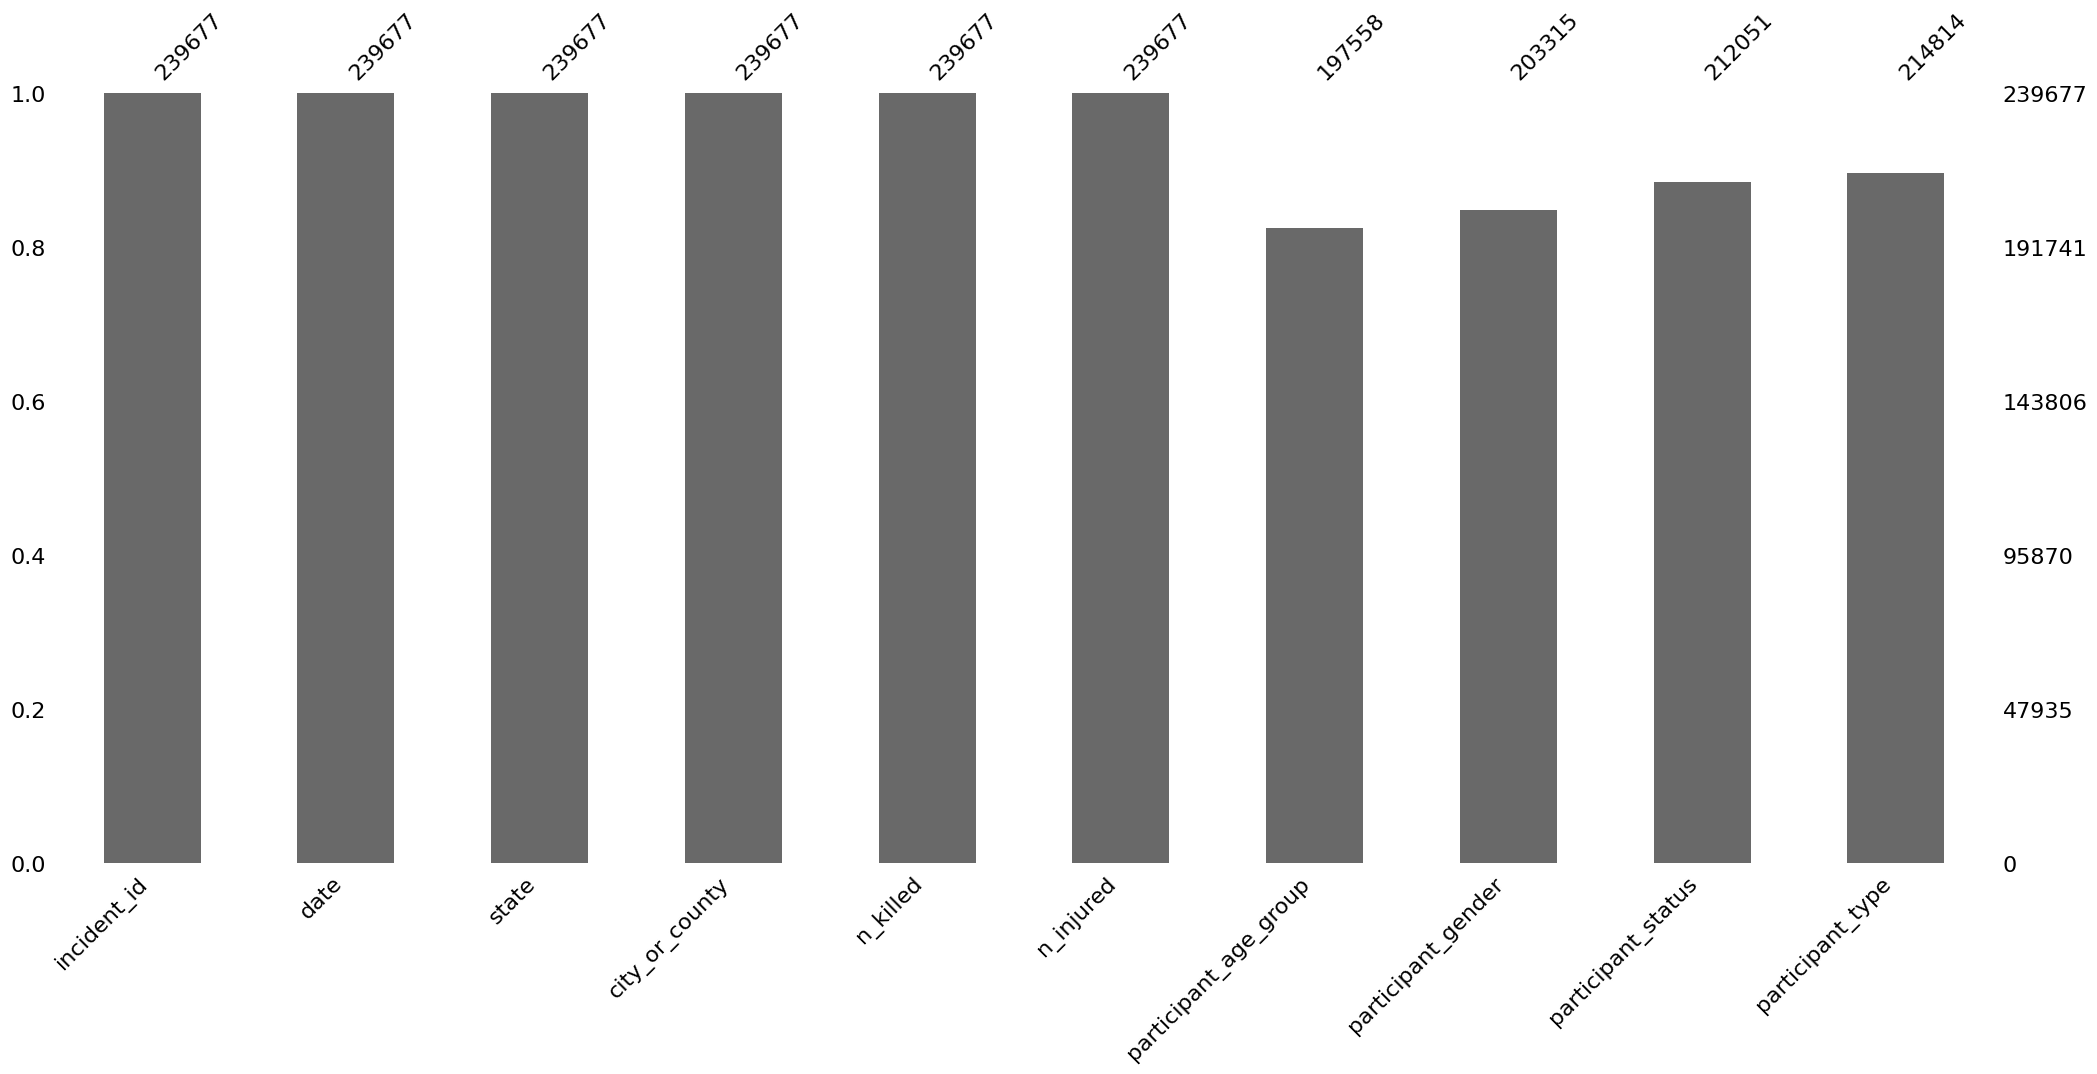

In [68]:
missda.bar(data)

In [69]:
data1 = data.copy()

In [70]:
data.head()

,incident_id,date,state,city_or_county,n_killed,n_injured,participant_age_group,participant_gender,participant_status,participant_type
0,461105,1/1/2013,Pennsylvania,Mckeesport,0,4,0::Adult 18+||1::Adult 18+||2::Adult 18+||3::A...,0::Male||1::Male||3::Male||4::Female,0::Arrested||1::Injured||2::Injured||3::Injure...,0::Victim||1::Victim||2::Victim||3::Victim||4:...
1,460726,1/1/2013,California,Hawthorne,1,3,0::Adult 18+||1::Adult 18+||2::Adult 18+||3::A...,0::Male,0::Killed||1::Injured||2::Injured||3::Injured,0::Victim||1::Victim||2::Victim||3::Victim||4:...
2,478855,1/1/2013,Ohio,Lorain,1,3,0::Adult 18+||1::Adult 18+||2::Adult 18+||3::A...,0::Male||1::Male||2::Male||3::Male||4::Male,"0::Injured, Unharmed, Arrested||1::Unharmed, A...",0::Subject-Suspect||1::Subject-Suspect||2::Vic...
3,478925,1/5/2013,Colorado,Aurora,4,0,0::Adult 18+||1::Adult 18+||2::Adult 18+||3::A...,0::Female||1::Male||2::Male||3::Male,0::Killed||1::Killed||2::Killed||3::Killed,0::Victim||1::Victim||2::Victim||3::Subject-Su...
4,478959,1/7/2013,North Carolina,Greensboro,2,2,0::Adult 18+||1::Adult 18+||2::Teen 12-17||3::...,0::Female||1::Male||2::Male||3::Female,0::Injured||1::Injured||2::Killed||3::Killed,0::Victim||1::Victim||2::Victim||3::Subject-Su...


In [71]:

ages_str = data.participant_age_group.astype('string')
ages_str = ages_str.replace({'\|\|':'|', '::':':'}, regex=True)
ages_str = ages_str.str.split('|')
ages_str.iloc[:] = ages_str.iloc[:].apply(
    lambda x: [item.split(':')[-1] for item in x] if isinstance(x, list) else []
)
ages_str.iloc[2]

<>:2: SyntaxWarning: invalid escape sequence '\|'
<>:2: SyntaxWarning: invalid escape sequence '\|'
C:\Users\Andro\AppData\Local\Temp\ipykernel_8880\3250287147.py:2: SyntaxWarning: invalid escape sequence '\|'
  ages_str = ages_str.replace({'\|\|':'|', '::':':'}, regex=True)


['Adult 18+', 'Adult 18+', 'Adult 18+', 'Adult 18+', 'Adult 18+']

In [72]:

gneder_str = data.participant_gender.astype('string')
gneder_str = gneder_str.replace({'\|\|':'|', '::':':'}, regex=True)
gneder_str = gneder_str.str.split('|')
gneder_str.iloc[:] = gneder_str.iloc[:].apply(
    lambda x: [item.split(':')[-1] for item in x] if isinstance(x, list) else []
)
gneder_str.iloc[2]

<>:2: SyntaxWarning: invalid escape sequence '\|'
<>:2: SyntaxWarning: invalid escape sequence '\|'
C:\Users\Andro\AppData\Local\Temp\ipykernel_8880\973681488.py:2: SyntaxWarning: invalid escape sequence '\|'
  gneder_str = gneder_str.replace({'\|\|':'|', '::':':'}, regex=True)


['Male', 'Male', 'Male', 'Male', 'Male']

In [73]:

status_str = data.participant_status.astype('string')
status_str = status_str.replace({'\|\|':'|', '::':':'}, regex=True)
status_str = status_str.str.split('|')
status_str.iloc[:] = status_str.iloc[:].apply(
    lambda x: [item.split(':')[-1] for item in x] if isinstance(x, list) else []
)
status_str.iloc[2]

<>:2: SyntaxWarning: invalid escape sequence '\|'
<>:2: SyntaxWarning: invalid escape sequence '\|'
C:\Users\Andro\AppData\Local\Temp\ipykernel_8880\2721160546.py:2: SyntaxWarning: invalid escape sequence '\|'
  status_str = status_str.replace({'\|\|':'|', '::':':'}, regex=True)


['Injured, Unharmed, Arrested',
 'Unharmed, Arrested',
 'Killed',
 'Injured',
 'Injured']

In [74]:

type_str = data.participant_type.astype('string')
type_str = type_str.replace({'\|\|':'|', '::':':'}, regex=True)
type_str = type_str.str.split('|')
type_str.iloc[:] = type_str.iloc[:].apply(
    lambda x: [item.split(':')[-1] for item in x] if isinstance(x, list) else []
)
type_str.iloc[2]

<>:2: SyntaxWarning: invalid escape sequence '\|'
<>:2: SyntaxWarning: invalid escape sequence '\|'
C:\Users\Andro\AppData\Local\Temp\ipykernel_8880\3460957395.py:2: SyntaxWarning: invalid escape sequence '\|'
  type_str = type_str.replace({'\|\|':'|', '::':':'}, regex=True)


['Subject-Suspect', 'Subject-Suspect', 'Victim', 'Victim', 'Victim']

In [75]:
data['participant_age_group'] = ages_str.values
data['participant_gender'] = gneder_str.values
data['participant_status'] = status_str.values
data['participant_type'] = type_str.values
data.head()

,incident_id,date,state,city_or_county,n_killed,n_injured,participant_age_group,participant_gender,participant_status,participant_type
0,461105,1/1/2013,Pennsylvania,Mckeesport,0,4,"[Adult 18+, Adult 18+, Adult 18+, Adult 18+, A...","[Male, Male, Male, Female]","[Arrested, Injured, Injured, Injured, Injured]","[Victim, Victim, Victim, Victim, Subject-Suspect]"
1,460726,1/1/2013,California,Hawthorne,1,3,"[Adult 18+, Adult 18+, Adult 18+, Adult 18+]",[Male],"[Killed, Injured, Injured, Injured]","[Victim, Victim, Victim, Victim, Subject-Suspect]"
2,478855,1/1/2013,Ohio,Lorain,1,3,"[Adult 18+, Adult 18+, Adult 18+, Adult 18+, A...","[Male, Male, Male, Male, Male]","[Injured, Unharmed, Arrested, Unharmed, Arrest...","[Subject-Suspect, Subject-Suspect, Victim, Vic..."
3,478925,1/5/2013,Colorado,Aurora,4,0,"[Adult 18+, Adult 18+, Adult 18+, Adult 18+]","[Female, Male, Male, Male]","[Killed, Killed, Killed, Killed]","[Victim, Victim, Victim, Subject-Suspect]"
4,478959,1/7/2013,North Carolina,Greensboro,2,2,"[Adult 18+, Adult 18+, Teen 12-17, Adult 18+]","[Female, Male, Male, Female]","[Injured, Injured, Killed, Killed]","[Victim, Victim, Victim, Subject-Suspect]"


In [76]:
def age_group_is_complete_fn(row):
    if (row.n_injured + row.n_killed) >= len(row.participant_age_group):
        return True
    else:
        return False

age_group_is_complete = data.apply(age_group_is_complete_fn,axis=1)
data['age_group_is_complete'] = age_group_is_complete
age_group_is_complete_count = data.loc[data.age_group_is_complete == True].age_group_is_complete.count()



In [77]:
def gender_is_complete_fn(row):
    if (row.n_injured + row.n_killed) >= len(row.participant_gender):
        return True
    else:
        return False

gender_is_complete= data.apply(gender_is_complete_fn,axis=1)
data['gender_is_complete'] = gender_is_complete
gender_is_complete_count = data.loc[data.gender_is_complete == True].gender_is_complete.count()

In [78]:
def status_is_complete_fn(row):
    if (row.n_injured + row.n_killed) >= len(row.participant_status):
        return True
    else:
        return False

status_is_complete= data.apply(status_is_complete_fn,axis=1)
data['status_is_complete'] = status_is_complete
status_is_complete_count = data.loc[data.status_is_complete == True].status_is_complete.count()

In [79]:
def type_is_complete_fn(row):
    if (row.n_injured + row.n_killed) >= len(row.participant_type):
        return True
    else:
        return False

type_is_complete= data.apply(type_is_complete_fn,axis=1)
data['type_is_complete'] = type_is_complete
type_is_complete_count = data.loc[data.type_is_complete == True].type_is_complete.count()

In [80]:
age_group_is_complete_ratio = round(age_group_is_complete_count/len(data.age_group_is_complete),2)*100
gender_is_complete_ratio = round(gender_is_complete_count/len(data.gender_is_complete),2)*100
status_is_complete_ratio = round(status_is_complete_count/len(data.status_is_complete),2)*100
type_is_complete_ratio = round(type_is_complete_count/len(data.type_is_complete),2)*100


In [81]:
print('age_group_is_complete: ',age_group_is_complete_count,' , ',age_group_is_complete_ratio,'%',sep='')
print('gender_is_complete: ',gender_is_complete_count,' , ',gender_is_complete_ratio,'%',sep='')
print('status_is_complete: ',status_is_complete_count,' , ',status_is_complete_ratio,'%',sep='')
print('type_is_complete: ',type_is_complete_count,' , ',type_is_complete_ratio,'%',sep='')

age_group_is_complete: 126060 , 53.0%
gender_is_complete: 116901 , 49.0%
status_is_complete: 110219 , 46.0%
type_is_complete: 105046 , 44.0%


In [82]:
data.city_or_county.describe()

count      239677
unique      12898
top       Chicago
freq        10814
Name: city_or_county, dtype: object

In [83]:
data.state.describe()

count       239677
unique          51
top       Illinois
freq         17556
Name: state, dtype: object

In [84]:
data.n_injured.describe()

count    239677.000000
mean          0.494007
std           0.729952
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max          53.000000
Name: n_injured, dtype: float64

In [85]:
data.loc[data.n_injured == 0].n_injured.count()

np.int64(142487)

In [86]:
data.iloc[data.n_injured==53]

,incident_id,date,state,city_or_county,n_killed,n_injured,participant_age_group,participant_gender,participant_status,participant_type,age_group_is_complete,gender_is_complete,status_is_complete,type_is_complete
130448,577157,6/12/2016,Florida,Orlando,50,53,"[Adult 18+, Adult 18+, Adult 18+, Adult 18+, A...","[Male, Male, Male, Male, Male, Male, Male, Fem...","[Killed, Killed, Killed, Killed, Killed, Kille...","[Victim, Victim, Victim, Victim, Victim, Victi...",True,True,True,True


In [87]:
data.n_killed.describe()

count    239677.000000
mean          0.252290
std           0.521779
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          50.000000
Name: n_killed, dtype: float64

In [88]:
data.loc[data.n_killed == 0].n_killed.count()

np.int64(185835)

In [89]:
data.loc[data.n_killed == 50]

,incident_id,date,state,city_or_county,n_killed,n_injured,participant_age_group,participant_gender,participant_status,participant_type,age_group_is_complete,gender_is_complete,status_is_complete,type_is_complete
130448,577157,6/12/2016,Florida,Orlando,50,53,"[Adult 18+, Adult 18+, Adult 18+, Adult 18+, A...","[Male, Male, Male, Male, Male, Male, Male, Fem...","[Killed, Killed, Killed, Killed, Killed, Kille...","[Victim, Victim, Victim, Victim, Victim, Victi...",True,True,True,True


In [ ]:
def count_victims_type(row):
    
    male_victim_count = 0
    female_victim_count = 0
    male_suspect_count = 0
    female_suspect_count = 0
    row_length = len(row.participant_gender)
    for i in range(row_length):
        if row.participant_gender[i] == 'Male':
            if row.participant_type[i] == 'Victim':
                male_victim_count +=1
            elif row.participant_type[i] == 'Subject-Suspect':
                male_suspect_count +=1

        elif row.participant_gender[i] == 'Female':
            if row.participant_type[i] == 'Victim':
                female_victim_count +=1
            elif row.participant_type[i] == 'Subject-Suspect':
                female_suspect_count +=1
        
    return [male_victim_count,female_victim_count,male_suspect_count,female_suspect_count]

gender_type_list = data.loc[data.gender_is_complete & data.type_is_complete & ((data.n_injured + data.n_killed) != 0)]
gender_type_list = gender_type_list.apply(
    count_victims_type,
    axis=1,
    result_type='expand'
)

gender_type_list.columns = [
    'male_victim',
    'female_victim',
    'male_suspect',
    'female_suspect'
]


,male_victim,female_victim,male_suspect,female_suspect
3,2,1,1,0
4,2,1,0,1
9,1,0,0,0
12,4,0,1,0
19,3,2,0,0
...,...,...,...,...
239663,0,0,1,0
239668,1,0,0,0
239674,1,0,0,0
239675,1,0,0,0


In [93]:
gender_type_list


,male_victim,female_victim,male_suspect,female_suspect
3,2,1,1,0
4,2,1,0,1
9,1,0,0,0
12,4,0,1,0
19,3,2,0,0
...,...,...,...,...
239663,0,0,1,0
239668,1,0,0,0
239674,1,0,0,0
239675,1,0,0,0


In [91]:
male_suspect_count = gender_type_list.male_suspect.sum()
female_suspect_count = gender_type_list.female_suspect.sum()
male_victim_count = gender_type_list.male_victim.sum()
female_victim_count = gender_type_list.female_victim.sum()
total_victim_count = male_victim_count + female_victim_count
total_suspect_count = male_suspect_count + female_suspect_count
male_suspect_ratio = round(male_suspect_count/total_suspect_count,2)*100
female_suspect_ratio = round(female_suspect_count/total_suspect_count,2)*100
male_victim_ratio = round(male_victim_count/total_victim_count,2)*100
female_victim_ratio = round(female_victim_count/total_victim_count,2)*100

In [92]:
print('male suspect: ',male_suspect_count,' , ',male_suspect_ratio,'%',sep='')
print('female suspect: ',female_suspect_count,' , ',female_suspect_ratio,'%',sep='')
print('male victim: ',male_victim_count,' , ',male_victim_ratio,'%',sep='')
print('female victim: ',female_victim_count,' , ',female_victim_ratio,'%',sep='')

male suspect: 10402 , 95.0%
female suspect: 539 , 5.0%
male victim: 69420 , 85.0%
female victim: 11974 , 15.0%
